In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx
import branca.colormap as c

import pyproj
from skgstat import Variogram


sns.set_style("whitegrid")

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import pyproj

def plot_semivariogram(df, value_col="res", lon_col="Longitude", lat_col="Latitude", n_lags=50, title=None, output_file=None):
    fig, ax = plt.subplots()

    # Project coordinates to EPSG:28992
    proj = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
    x, y = proj.transform(df[lon_col].values, df[lat_col].values)
    coords = np.column_stack([x, y])

    values = df[value_col].values

    # Compute variogram
    V = Variogram(coords, values, n_lags=n_lags)

    # Plot experimental points
    ax.scatter(V.bins/1000, V.experimental, alpha=0.5)

    # Plot fitted model line
    x_fit = np.linspace(0, V.bins.max(), 200)
    ax.plot(x_fit/1000, V.fitted_model(x_fit))

    # Labels and title
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Semivariance")
    if title is not None:
        ax.set_title(title)

    fig.tight_layout()

    # Save figure if filename provided
    if output_file is not None:
        fig.savefig(output_file, bbox_inches="tight")

    plt.show()


def plot_feature_importance(df, feature_col="feature", importance_col="importance_gain",
                            title="Feature Importances", output_file=None, top_n=None):
    df_plot = df.sort_values(by=importance_col, ascending=False)
    if top_n is not None:
        df_plot = df_plot.head(top_n)
    
    plt.figure(figsize=(8, max(4, 0.3*len(df_plot))))
    sns.barplot(x=importance_col, y=feature_col, data=df_plot)
    
    plt.xlabel("Importance (Gain)")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, bbox_inches="tight")
    
    plt.show()


def plot_spatial_residuals(df, value_col="res", lon_col="Longitude", lat_col="Latitude",
                           title="Spatial distribution of residuals", 
                           cmap="plasma", markersize=20, output_file=None):

    # Remove missing values
    df_clean = df.dropna(subset=[lon_col, lat_col, value_col]).copy()

    # Compute mean residual per unique location
    df_map = df_clean.groupby([lon_col, lat_col], as_index=False)[value_col].mean()

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_map,
        geometry=gpd.points_from_xy(df_map[lon_col], df_map[lat_col]),
        crs="EPSG:4326"
    )

    # Reproject to Web Mercator
    gdf = gdf.to_crs(epsg=3857)

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot points
    gdf.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        markersize=markersize,
        alpha=0.7,
        legend=True,
        legend_kwds={'label': value_col, 'shrink': 0.7}
    )

    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_axis_off()
    ax.set_title(title)
    fig.tight_layout()

    # Save figure if requested
    if output_file:
        fig.savefig(output_file, bbox_inches="tight")

    plt.show()

# Linear regression

In [118]:
df_results_lm_jan= pd.read_csv('outputs_aggregated_jan/cv_predictions_linear.csv')
df_results_lm_april= pd.read_csv('outputs_aggregated_april/cv_predictions_linear.csv')

lm_feature_importances_jan = pd.read_csv('outputs_aggregated_jan/linear_model_coefficients.csv')
lm_feature_importances_april = pd.read_csv('outputs_aggregated_april/linear_model_coefficients.csv')

In [119]:
df_results_lm_jan["res"] =  df_results_lm_jan["Value"] - df_results_lm_jan["linear_pred"]
df_results_lm_april["res"] =  df_results_lm_april["Value"] - df_results_lm_april["linear_pred"]

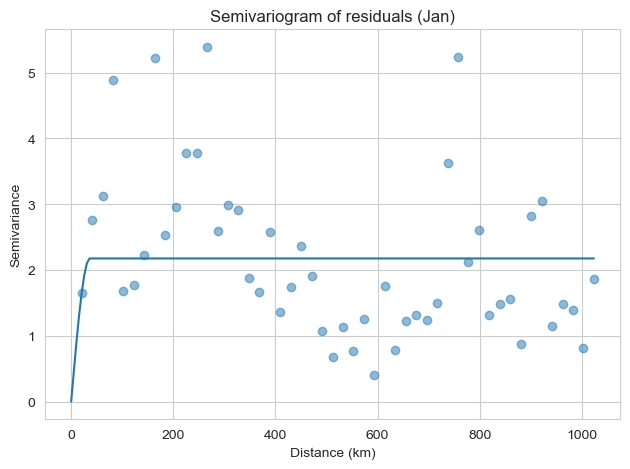

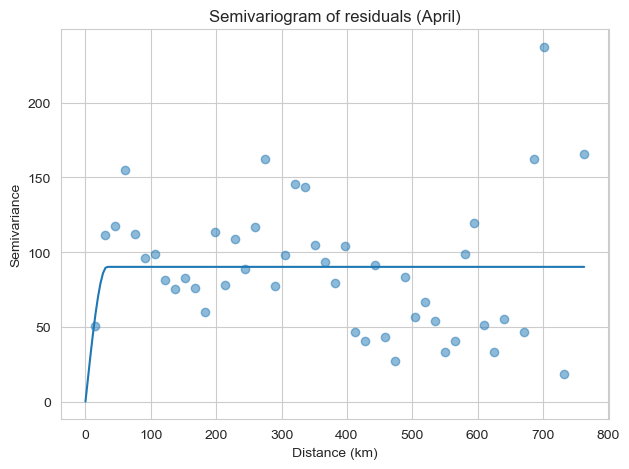

In [120]:
plot_semivariogram(df_results_lm_jan, title="Semivariogram of residuals (Jan)", output_file="output/semivariogram_residuals_lm_jan.pdf")
plot_semivariogram(df_results_lm_april, title="Semivariogram of residuals (April)", output_file="output/semivariogram_residuals_lm_april.pdf")

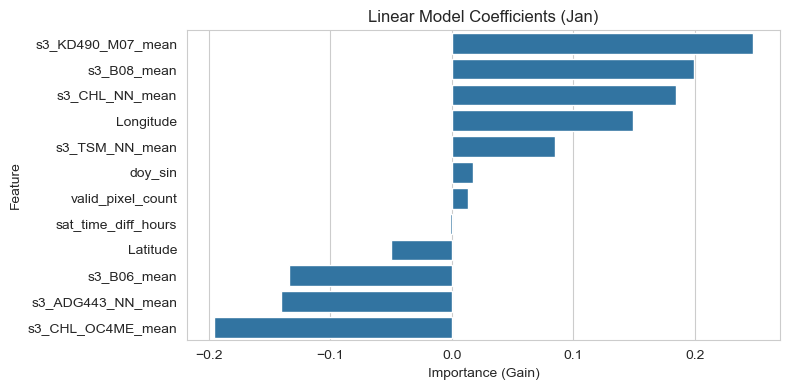

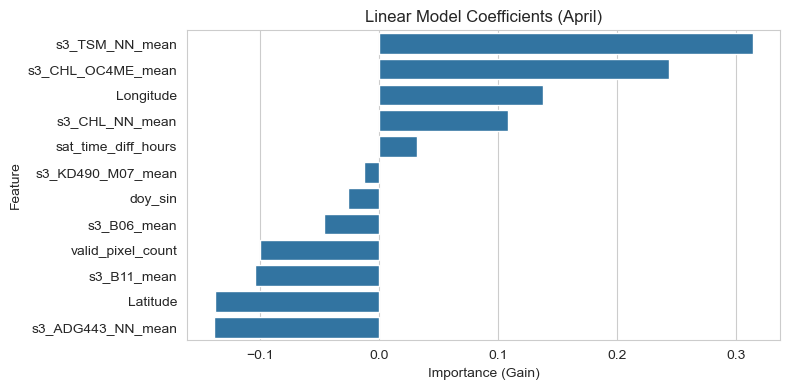

In [121]:
plot_feature_importance(lm_feature_importances_jan,importance_col= "coefficient_standardized", title="Linear Model Coefficients (Jan)", output_file="output/lm_feature_importances_jan.pdf", top_n=20)
plot_feature_importance(lm_feature_importances_april,importance_col= "coefficient_standardized", title="Linear Model Coefficients (April)", output_file="output/lm_feature_importances_april.pdf", top_n=20)

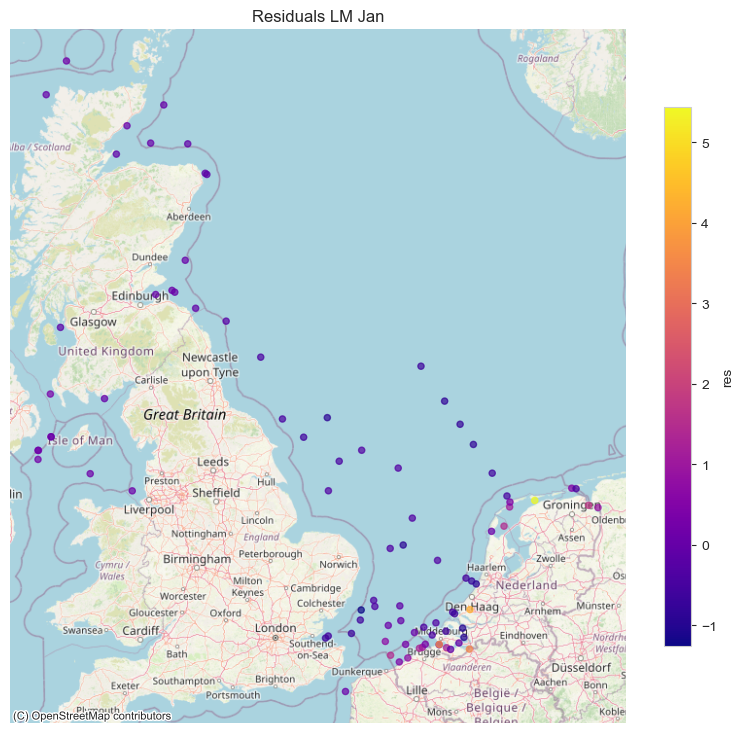

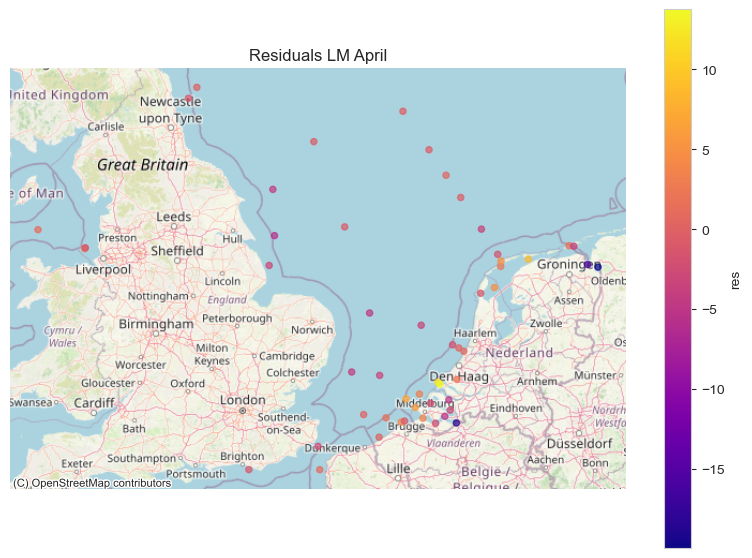

In [122]:
plot_spatial_residuals(df_results_lm_jan, value_col="res", title="Residuals LM Jan", 
                       output_file="output/residuals_lm_jan.pdf")
plot_spatial_residuals(df_results_lm_april, value_col="res", title="Residuals LM April", 
                       output_file="output/residuals_lm_april.pdf")

# RF

In [123]:
df_results_rf_jan= pd.read_csv('outputs_aggregated_jan/cv_predictions_random_forest.csv')
df_results_rf_april= pd.read_csv('outputs_aggregated_april/cv_predictions_random_forest.csv')

rf_feature_importances_jan = pd.read_csv('outputs_aggregated_jan/rf_feature_importances.csv')
rf_feature_importances_april = pd.read_csv('outputs_aggregated_april/rf_feature_importances.csv')

In [124]:
df_results_rf_jan["res"] =  df_results_rf_jan["Value"] - df_results_rf_jan["random_forest_pred"]
df_results_rf_april["res"] =  df_results_rf_april["Value"] - df_results_rf_april["random_forest_pred"]

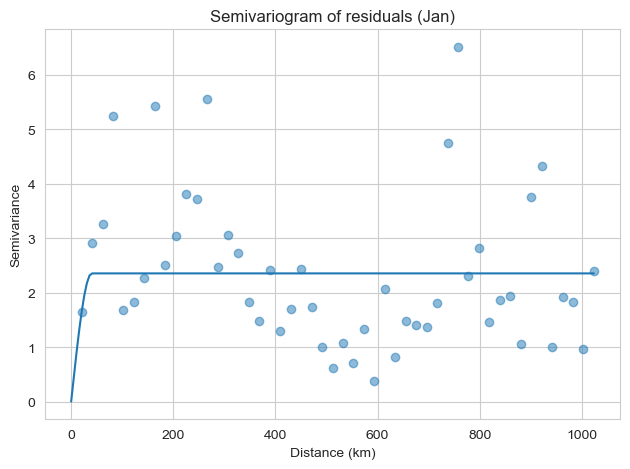

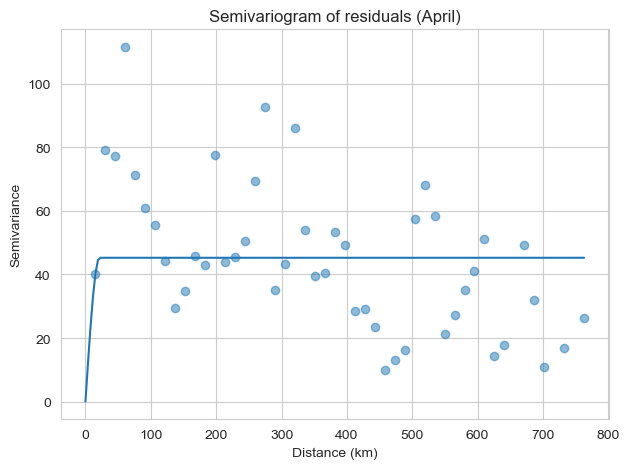

In [125]:
plot_semivariogram(df_results_rf_jan, title="Semivariogram of residuals (Jan)", output_file="output/semivariogram_residuals_rf_jan.pdf")
plot_semivariogram(df_results_rf_april, title="Semivariogram of residuals (April)", output_file="output/semivariogram_residuals_rf_april.pdf")

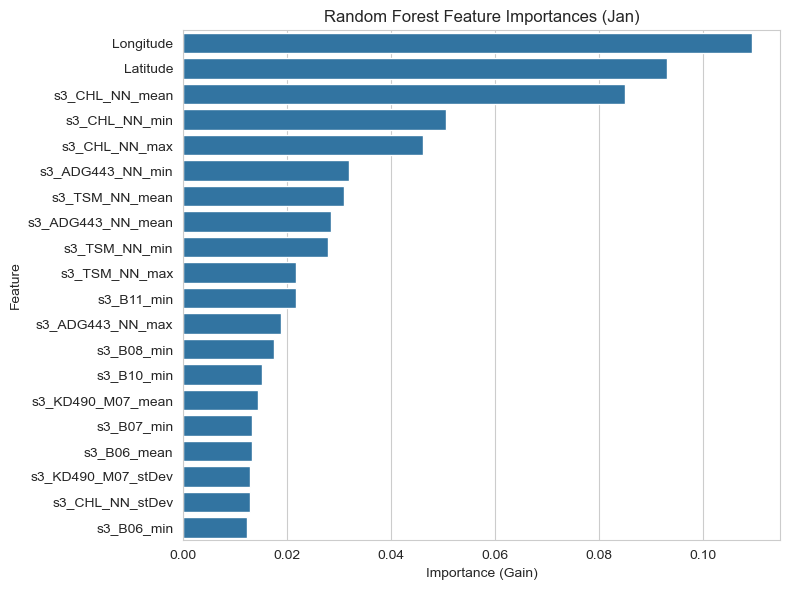

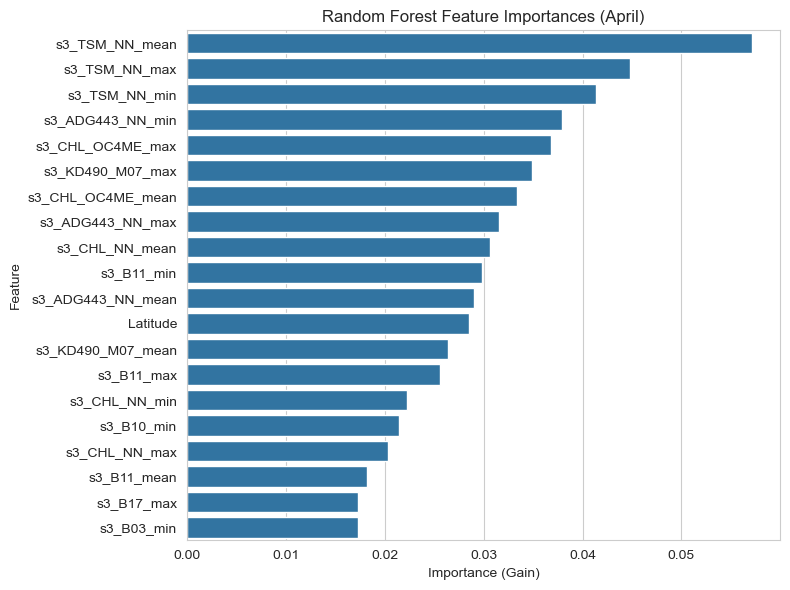

In [126]:
plot_feature_importance(rf_feature_importances_jan,importance_col= "importance", title="Random Forest Feature Importances (Jan)", output_file="output/rf_feature_importances_jan.pdf", top_n=20)
plot_feature_importance(rf_feature_importances_april,importance_col= "importance", title="Random Forest Feature Importances (April)", output_file="output/rf_feature_importances_april.pdf", top_n=20)

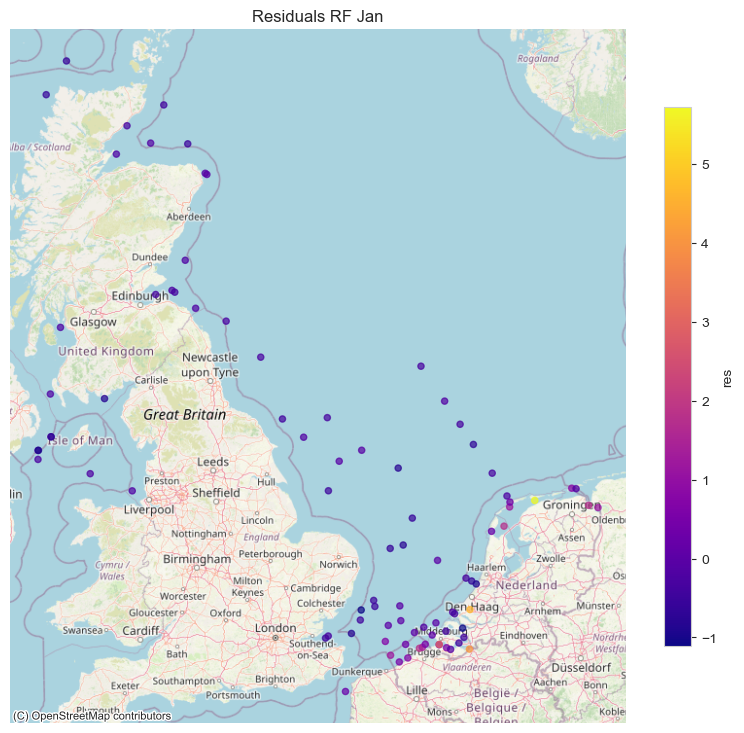

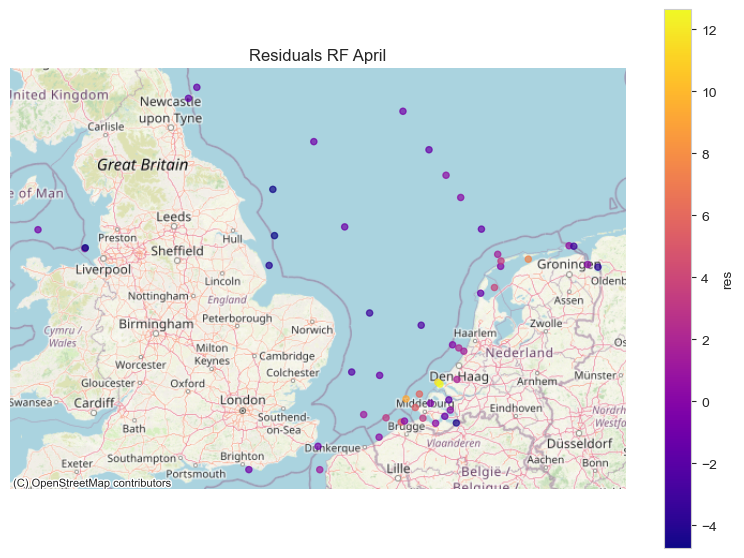

In [127]:
plot_spatial_residuals(df_results_rf_jan, value_col="res", title="Residuals RF Jan", 
                       output_file="output/residuals_rf_jan.pdf")
plot_spatial_residuals(df_results_rf_april, value_col="res", title="Residuals RF April", 
                       output_file="output/residuals_rf_april.pdf")

# XGBoost

In [128]:
df_results_xgboost_jan= pd.read_csv('outputs_aggregated_jan/cv_predictions_xgboost.csv')
df_results_xgboost_april= pd.read_csv('outputs_aggregated_april/cv_predictions_xgboost.csv')

xgb_feature_importances_jan = pd.read_csv('outputs_aggregated_jan/xgb_feature_importances.csv')
xgb_feature_importances_april = pd.read_csv('outputs_aggregated_april/xgb_feature_importances.csv')

In [82]:
df_results_xgboost_jan["res"] =  df_results_xgboost_jan["Value"] - df_results_xgboost_jan["xgboost_pred"]
df_results_xgboost_april["res"] =  df_results_xgboost_april["Value"] - df_results_xgboost_april["xgboost_pred"]

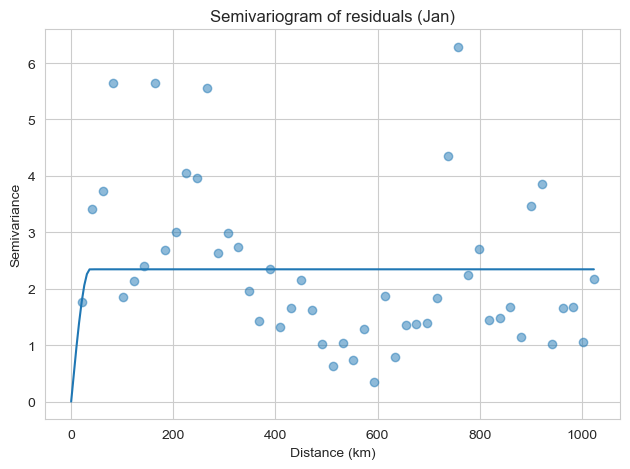

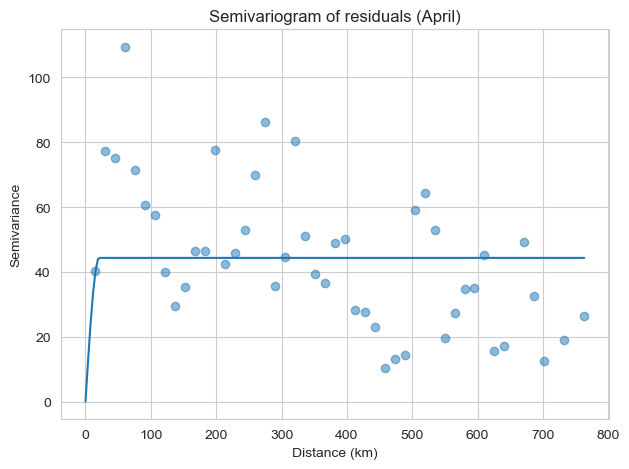

In [83]:
plot_semivariogram(df_results_xgboost_jan, title="Semivariogram of residuals (Jan)", output_file="output/semivariogram_residuals_xgboost_jan.pdf")
plot_semivariogram(df_results_xgboost_april, title="Semivariogram of residuals (April)", output_file="output/semivariogram_residuals_xgboost_april.pdf")

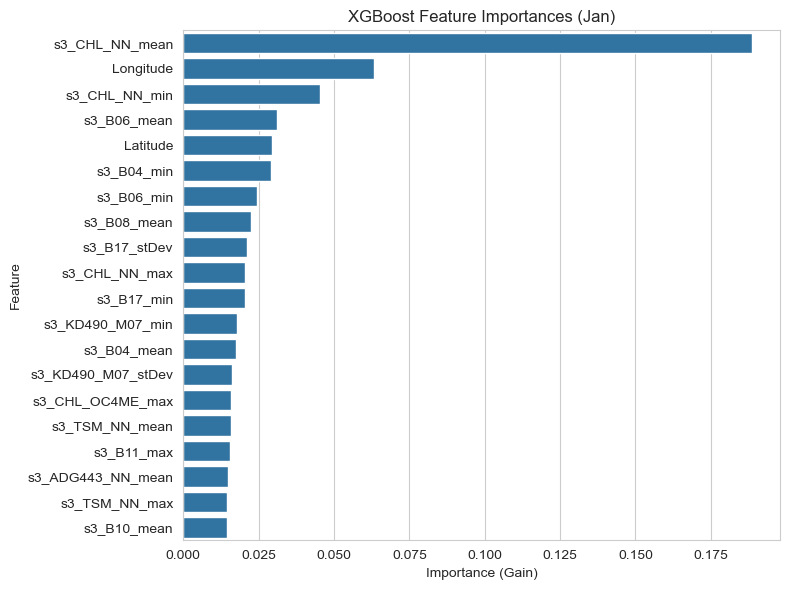

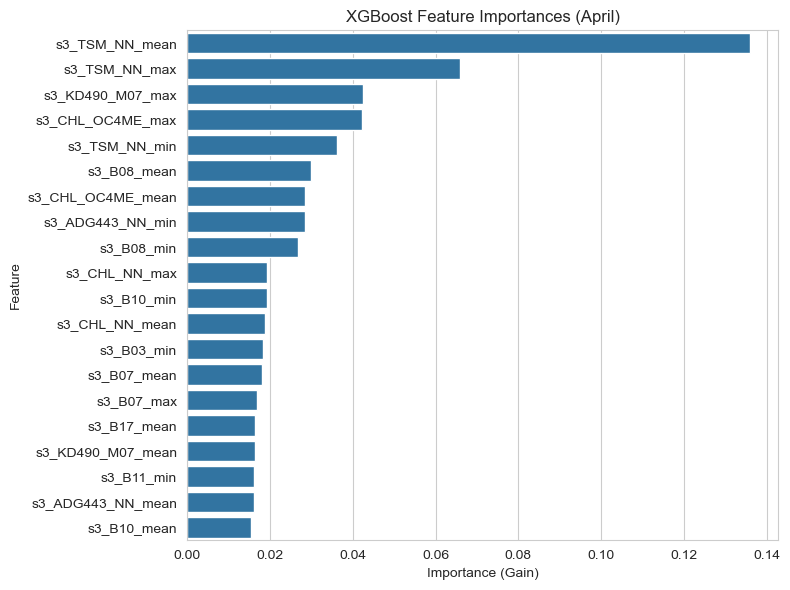

In [84]:
plot_feature_importance(xgb_feature_importances_jan, title="XGBoost Feature Importances (Jan)", output_file="output/xgb_feature_importances_jan.pdf", top_n=20)
plot_feature_importance(xgb_feature_importances_april, title="XGBoost Feature Importances (April)", output_file="output/xgb_feature_importances_april.pdf", top_n=20)

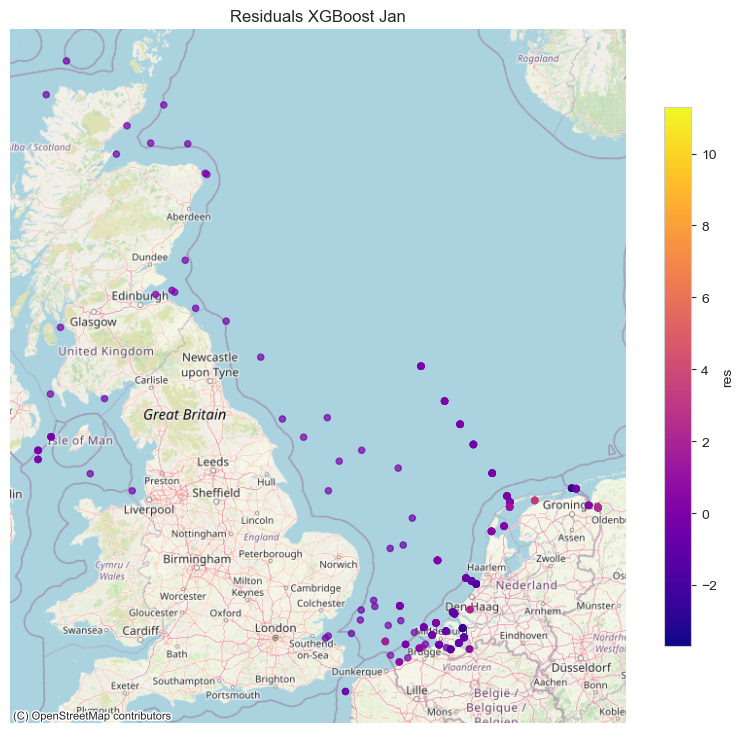

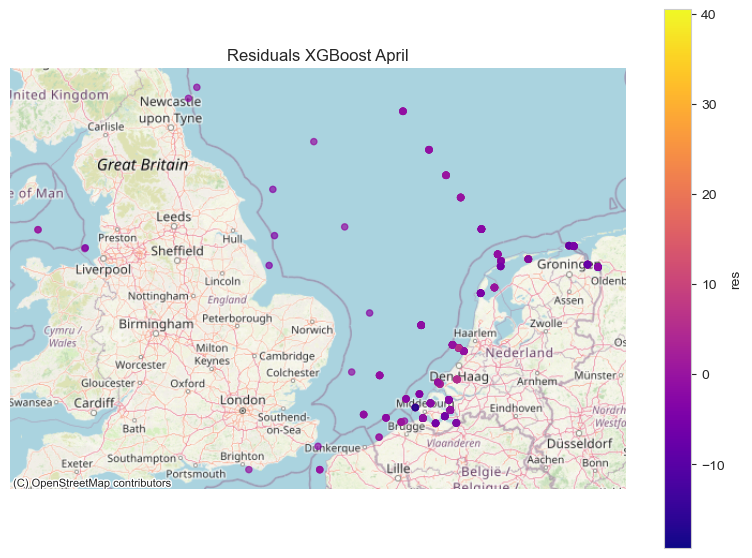

In [116]:
plot_spatial_residuals(df_results_xgboost_jan, value_col="res", title="Residuals XGBoost Jan", 
                       output_file="output/residuals_xgboost_jan.pdf")
plot_spatial_residuals(df_results_xgboost_april, value_col="res", title="Residuals XGBoost April", 
                       output_file="output/residuals_xgboost_april.pdf")